# Experimentation with model

### Imports

In [68]:
%load_ext autoreload
%autoreload 2

# from transformers import AutoTokenizer, set_seed
import os, torch
import sys, argparse, time
# import inspect
import numpy as np
# from vllm import LLM, SamplingParams

sys.path.append("src") 
from llama_activate import (
    # get_llm,
    build_network,
    run_simulation,
    main, 
    call_visualizations,
    # pca_visualize
    
)

from utils.tools.path_manager import PathManager

import utils.metrics as metrics
from utils.tools.path_manager import PathManager
from classes.network import RandomNetwork, SocialDistanceAttachment
# import utils.tools.load_personas as lp
import utils.visualization as vis
# import utils.tools.reading_in as ri
import warnings

# Suppress annoying warning
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.io.spss")

# --- Model Configuration ---
# llama_model = "meta-llama/Meta-Llama-3.1-8B-Instruct" #bigger model
# MODEL_ID = os.environ.get("LLAMA_ID", llama_model)
# CACHE_DIR = os.environ.get("TRANSFORMERS_CACHE", None)
# SEED = 1234
# set_seed(SEED)

print("Is CUDA available:", torch.cuda.is_available())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Is CUDA available: False


### power law distributionn PHQ-9 data

In [ ]:
# --- Quick check: is the PHQ-9 sum-score distribution heavy-tailed (power-law)? ---
# Uses the project's own loader (utils/tools/load_personas.load_phq9) instead of
# touching the .sav directly. load_phq9 returns a random sample but also writes
# EVERY valid row to phq9_filtered.csv, so we use that file to size the population
# and then pull the whole set back through the loader.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw
from utils.tools.load_personas import load_phq9

BLUE, ORANGE, GREY = "#1f77b4", "#d96907", "#888888"


load_phq9(personass_to_load=1)  # refresh phq9_filtered.csv (side-effect)
n_total = len(pd.read_csv("data/confidential/phq9_filtered.csv"))

records = load_phq9(personass_to_load=n_total)  # all valid rows, via the loader
phq9 = np.array([r["phq9_sumscore"] for r in records], dtype=float)

print(f"n = {phq9.size}  |  min={phq9.min():.0f}  max={phq9.max():.0f}  "
      f"mean={phq9.mean():.2f}  median={np.median(phq9):.0f}")

# Fit a discrete power law and compare it against a log-normal alternative.
# powerlaw needs positive values, so its automatic xmin search ignores 0-scores.
fit = powerlaw.Fit(phq9, discrete=True)


In [ ]:
R, p = fit.distribution_compare("power_law", "lognormal", normalized_ratio=True)

# Empirical PDF: one dot per integer sum-score (>= xmin).
xmin = int(fit.power_law.xmin)
vals, counts = np.unique(phq9[phq9 >= xmin], return_counts=True)
pdf = counts / counts.sum()

# Power-law fit by least-squares ON THE DENSITY POINTS (each score weighted equally).
slope, intercept = np.polyfit(np.log10(vals), np.log10(pdf), 1)
gamma = -slope
print(f"OLS power-law fit on PDF: gamma={gamma:.3f}  xmin={xmin}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 3))
ax1.hist(phq9, bins=np.arange(phq9.min(), phq9.max() + 2) - 0.5,
         weights=np.ones_like(phq9, dtype=float) / len(phq9),
         color=BLUE, edgecolor="white")
ax1.set(xlabel="PHQ-9 sum-score")
ax1.set_xlim(0)

ax2.plot(vals, pdf, "o", color=BLUE,  markersize = 4, label="empirical")
xx = np.array([vals.min(), vals.max()], dtype=float)
ax2.plot(xx, 10 ** (intercept + slope * np.log10(xx)),
         color=ORANGE, linestyle="--", label="power-law fit")
ax2.set(xlabel="PHQ-9 sum-score", xscale="log", yscale="log")
ax2.legend(loc="lower left")

fig.supylabel("PDF")
ax1.text(0.5, -0.32, "(a) Distribution", transform=ax1.transAxes, ha="center", va="top")
ax2.text(0.5, -0.32, rf"(b) Power-law fit ($\gamma$ = {gamma:.2f})",
         transform=ax2.transAxes, ha="center", va="top")

plt.tight_layout()
plt.savefig("plots/phq9_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Do prompt robustness analyses

Prompt sensitivity analysis
Builds a pairwise cosim heatmap that includes the un-optimised ("minimal") prompt
as the last row/column. Cell colour = cosine similarity; annotation = mean test
score of the two runs (the diagonal shows that run's own score). The minimal
row/column has no annotation since it has no test score.

Runs are sorted by test score so the top-left of each heatmap is the best run
(PHQ-9: low MAE = good, so ascending; post-gen: high quality = good, so descending).
Tick labels are the test scores themselves; the seed is shown in parentheses for
traceability without breaking the score-sorted ordering.


In [62]:
from src.utils.sensitivity.sa_analyze import (
    load_best_prompts, load_test_scores, load_minimal_score,
    compute_prompt_robustness, _sort_by_score,
    plot_prompt_sensitivity_pair
)
import json
import numpy as np


In [63]:
model = "Qwen3.5-27B"

seeds_phq9     = [23, 24, 25, 32, 33]
seeds_post_gen = [24, 25, 28, 29, 53]

with open("data/prompts_post.json") as f:
    minimal_phq9 = json.load(f)["phq9"]["system_instruction"]

with open("data/prompts_post_minimal.json") as f:
    _raw = json.load(f)["tweet_gen"]["system_forced"]
_rules, _rest    = _raw.split("### RULES ###", 1)
_rules_body, _   = _rest.split("### CONSTRAINTS ###", 1)
minimal_post_gen = "### RULES ###" + _rules_body.rstrip()

prompts_phq9     = load_best_prompts(model, seeds_phq9,     prompt_type="phq9")
prompts_post_gen = load_best_prompts(model, seeds_post_gen, prompt_type="post_gen")
test_phq9        = load_test_scores(model, seeds_phq9,      prompt_type="phq9")
test_post_gen    = load_test_scores(model, seeds_post_gen,  prompt_type="post_gen")

minimal_score_phq9     = load_minimal_score(model, seeds_phq9,     prompt_type="phq9")
minimal_score_post_gen = load_minimal_score(model, seeds_post_gen, prompt_type="post_gen")

prompts_phq9, test_phq9, seeds_phq9, labels_phq9 = _sort_by_score(
    prompts_phq9, test_phq9, seeds_phq9, ascending=True
)
prompts_post_gen, test_post_gen, seeds_post_gen, labels_post_gen = _sort_by_score(
    prompts_post_gen, test_post_gen, seeds_post_gen, ascending=False
)

rob_phq9 = compute_prompt_robustness(
    prompts_phq9, test_scores=test_phq9,
    baseline_prompt=minimal_phq9, baseline_score=minimal_score_phq9,
    labels=labels_phq9,
)
rob_post_gen = compute_prompt_robustness(
    prompts_post_gen, test_scores=test_post_gen,
    baseline_prompt=minimal_post_gen, baseline_score=minimal_score_post_gen,
    labels=labels_post_gen,
)

for name, rob in [("PHQ-9", rob_phq9), ("Post-gen", rob_post_gen)]:
    sim = np.array(rob["sim_matrix"])
    off_mask = ~np.eye(len(sim), dtype=bool)
    print(name, "n=", len(rob["labels"]), "mean off-diag cosine:", round(sim[off_mask].mean(), 3))


[2026-06-21 19:47:27] INFO SentenceTransformer.py:219: Use pytorch device_name: cpu
[2026-06-21 19:47:27] INFO SentenceTransformer.py:227: Load pretrained SentenceTransformer: all-MiniLM-L6-v2
[2026-06-21 19:47:34] INFO SentenceTransformer.py:219: Use pytorch device_name: cpu
[2026-06-21 19:47:34] INFO SentenceTransformer.py:227: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


PHQ-9 n= 6 mean off-diag cosine: 0.692
Post-gen n= 6 mean off-diag cosine: 0.721


In [64]:
plot_prompt_sensitivity_pair(rob_phq9, rob_post_gen, model_name=model)

Pair sensitivity plot → data/test_post/optimized_phq9/Qwen3.5-27B_sensitivity/prompt_sensitivity_pair.png


'data/test_post/optimized_phq9/Qwen3.5-27B_sensitivity/prompt_sensitivity_pair.png'

In [ ]:
# Output-cosine (left) + prompt-string (right) heatmaps for the post-gen prompts.
# iter_10 (human-optimized) is treated like any textgrad run: one more row, sorted
# by its test score, with a '(h)' tag on the label. Its score is READ from its
# eval_meta.txt (it has no training_trajectory.csv). The LEFT panel needs iter_10
# replicates: sa_prompt_baseline_run.sh now includes iter_10 -> run it + sa_embed:
#   bash src/utils/sensitivity/sa_prompt_baseline_run.sh
#   PYTHONPATH=src python -m utils.sensitivity.sa_embed \
#       --root data/prompt_optimization_h/qwen27_baseline/prompt_sa_reps
from src.utils.sensitivity.sa_analyze import (
    load_best_prompts, load_test_scores, compute_prompt_robustness,
    plot_prompt_output_string_pair)

seeds = [24, 25, 28, 29, 53]
iter10_dir = "data/prompt_optimization_h/qwen27_baseline/iter_10"
iter10_score = float(next(l.split(":", 1)[1]
                         for l in open(f"{iter10_dir}/eval_meta.txt")
                         if l.startswith("mean_score")))

# (reps-tree label, prompt text, test score, display label) — one row per prompt
rows = [(f"textgrad_seed{s}", p, sc, f"{sc:.2f}")
        for s, p, sc in zip(seeds,
                            load_best_prompts(model, seeds, prompt_type="post_gen"),
                            load_test_scores(model, seeds, prompt_type="post_gen"))]
rows.append(("iter_10", open(f"{iter10_dir}/prompt.txt").read().strip(),
             iter10_score, f"{iter10_score:.2f} (h)"))
rows.sort(key=lambda r: r[2], reverse=True)   # best (highest quality) first

rob = compute_prompt_robustness(
    [r[1] for r in rows], test_scores=[r[2] for r in rows],
    baseline_prompt=minimal_post_gen, baseline_score=minimal_score_post_gen,
    labels=[r[3] for r in rows])
plot_prompt_output_string_pair(rob, reps_labels=[r[0] for r in rows], model_name=model)

### Optimization run summaries
For each seed: best validation row, the train metric at that same step, the final test score (with std), and (for prompt optimisers) the optimised instruction. BERT block lists the hyperparameter set used at training time — verify if you re-run with different settings.

In [58]:
from src.utils.sensitivity.sa_analyze import (
    summarize_prompt_runs, print_prompt_summary,
)
import pandas as pd

MODEL_SHORT = "Qwen3.5-27B"
BASE_PHQ9   = "data/test_post/optimized_phq9"
BASE_TWEETS = "data/test_post/optimized_tweets"

phq9_seeds = [23, 24, 25, 32, 33]
phq9_df = summarize_prompt_runs(BASE_PHQ9, phq9_seeds, prompt_type="phq9",
                                 best_is="min", model_short=MODEL_SHORT)
print_prompt_summary(phq9_df, "PHQ-9 prompt optimization (MAE, lower=better)")



=== PHQ-9 prompt optimization (MAE, lower=better) ===

 seed  best_step  best_val  best_val_std  train_at_best  train_std  test_mean  test_std  test_n  batch_size  val_size  num_steps
   23          6     3.475         2.683          5.714      4.233      3.833     3.143    1200           7        40          8
   24          7     3.725         3.339          4.000      2.390      4.297     3.921    1200           7        40          8
   25          8     3.850         3.582          1.286      1.385      4.118     3.481    1200           7        40          8
   32          3     3.850         3.062          4.714      3.806      3.590     2.654    1200           7        40          8
   33          1     3.375         2.717          5.286      3.806      4.230     3.844    1200           7        40          8

--- Optimized instructions ---

[seed 23]  best_step=6  val=3.48  test=3.83
  Fill in the PHQ-9 questionnaire based on the post history. Map specific textual cues to eac

In [59]:
postgen_seeds = [24, 25, 28, 29, 52, 53]
postgen_df = summarize_prompt_runs(BASE_TWEETS, postgen_seeds, prompt_type="tweet",
                                    best_is="max", model_short=MODEL_SHORT)
print_prompt_summary(postgen_df, "Post-generation prompt optimization (quality score 0-10, higher=better)")



=== Post-generation prompt optimization (quality score 0-10, higher=better) ===

 seed  best_step  best_val  best_val_std  train_at_best  train_std  test_mean  test_std  test_n  batch_size  val_size  num_steps
   24          6     6.450         1.936          5.500      1.500       6.27     1.448     100           7        20          8
   25          5     6.950         1.532          6.167      1.213       6.39     1.490     100           7        20          8
   28          4     7.200         1.364          6.429      1.400       6.47     1.598     100           5        20          8
   29          1     7.421         1.426          4.833      0.898       6.74     1.284     100           6        20          8
   53          3     6.600         0.970          6.571      1.678       6.34     1.526     100           7        20          8

--- Optimized instructions ---

[seed 24]  best_step=6  val=6.45  test=6.27
  ### RULES ### Base your TONE and MOOD on your well-being (PHQ-9):

In [ ]:
from src.utils.sensitivity.sa_analyze import summarize_bert_runs

BERT_HYPERPARAMS = {
    "architecture":   "Linear -> 64 -> 32 -> 1 (ReLU, dropout 0.2)",
    "input_dim":      "768 x 3 (MentalBERT mean || max || std)",
    "optimizer":      "Adam (no weight decay)",
    "learning_rate":  1e-4,
    "loss":           "HuberLoss(delta=1.0); MAE tracked separately",
    "lr_schedule":    "ReduceLROnPlateau(factor=0.6, patience=3)",
    "grad_clip":      "max_norm=1.0",
    "batch_size":     8,
    "max_epochs":     30,
}

bert_df = summarize_bert_runs(model_short=MODEL_SHORT)

print("=== BERT regression hyperparameters (training-time config) ===")
for k, v in BERT_HYPERPARAMS.items():
    print(f"  {k:<14} = {v}")

print("=== BERT regression — per-seed summary ===")
if bert_df.empty:
    print("(no BERT runs found)")
else:
    print(bert_df.round(3).to_string(index=False))


### Set variables

In [1]:
# --- Simulation Variables ---

# ── Simulation parameters ──────────────────────────────────────────────────
ROUNDS=300
NUM_AGENTS=100
# DEGREE=4.5
SEEDS=(17)   # 5 seeds for multi-run calibration

# Optimal SDA topology parameters
# Previous (2026-06-10): ALPHA=2.1655  LATENT_WEIGHT=7.9839  DIM=5  AGE_WEIGHT=2.3149
# ALPHA=3.4312
# LATENT_WEIGHT=19.9048
# DIM=4
# AGE_WEIGHT=2.5259
# N_CLUSTERS=2            # match calibration (N_CLUSTERS_FIXED=2 in sa_network)

ALPHA=2.1655
LATENT_WEIGHT=7.9839
DIM=5
AGE_WEIGHT=1.3149
N_CLUSTERS=2            # match calibration (N_CLUSTERS_FIXED=2 in sa_network)

# ALPHA=4.9429
STUB_GAMMA=1.6187        # power-law exponent for the SDC stub degree sequence
# DEGREE=8.2539            # target mean fed in; realized mean degree ≈ 5.67 (stub shortfall)
# DIM=3
# N_CLUSTERS=2
# LATENT_WEIGHT=18.3813
# AGE_WEIGHT=2.2095

# Checkpointing / saving
CHECK_POINT=10          # PHQ-9 update cadence (every 10 rounds)
LOG=20               

rounds = 300
num_agents = 100
net = "sdc"
seeds = [18]
alpha = ALPHA
degree = DEGREE
init_phq9_zero = True
# p = 0.3
# k = 0
dim = DIM
save = True

# Define the states you want to run (["basis", "depressed"])
states = ["basis"] 

# Create the Namespace (mimicking argparse)
args = argparse.Namespace(
    net=net,
    rounds=rounds,
    num_agents=num_agents,
    seed=seeds[0], # Initial default, will be overwritten in loop
    seeds=seeds,   # List of seeds
    # m=m,
    # p=p,
    # k=k,
    stub_gamma=STUB_GAMMA,
    init_phq9_zero=init_phq9_zero,
    age_weight=AGE_WEIGHT,
    latent_weight=LATENT_WEIGHT,
    n_clusters = N_CLUSTERS,
    depressed=False,
    enforce_ngrams=False,
    alpha=alpha,
    degree=DEGREE,
    dim=dim,
    save=save,
    use_saved_network=0, # Set to integer if updating existing
    directed=False
)

# network = build_network(args)

NameError: name 'DEGREE' is not defined

## Get Network Features

In [ ]:
all_networks_results = main(args, None, states = ["basis"])
network_results = all_networks_results["basis"][0]
network = network_results["network"]
running_fracs = network_results["running_fracs"]
fracs_dist_step = network_results["fracs_dist_step"]
path_manager = PathManager(network=network)

cd_results = metrics.all_agent_phq9_cd(network, window_size=6, shift=6)

# Get paths
data_path = path_manager.get_run_directory(is_plot=False)
plot_path = path_manager.get_run_directory(is_plot=True)
data_filename = path_manager.get_network_filename()
plot_filename = path_manager.get_plot_name()

vis.plot_agent_cd_heatmaps(network, window=6, cd_results=cd_results, metric_name="PHQ-9", path=plot_path, filename=plot_filename, shift=6)

#Maybe bit ugly here but aggregate degree weighted phq9 scores
deg_w_phq9 = metrics.degree_weighted_mean(network)
vis.plot_degree_weighted_phq9(np.array([deg_w_phq9]), plot_path, plot_filename, save=args.save)
call_visualizations(
    network, 
    plot_path, 
    plot_filename, 
    args, 
    running_fracs, 
    fracs_dist_step)

# pca_visualize(all_networks_results, plot_path, plot_filename, args, num_steps=30, shift=5)

### PHQ-9 distribution shift by debiasing setting (degree-0)

Initial (r=0) vs end (r=300) PHQ-9 distributions for four debiasing conditions (all degree-0, no network). No debiasing best preserves the initial population distribution; the corrected runs collapse onto the PHQ-9=0 boundary (bimodal, with a small absorption at 27).

In [ ]:
# === PHQ-9 distribution: initial (r=0) vs end (r=300), by debiasing setting ===
# Degree-0 runs (no network) under 4 PHQ-9 debiasing conditions. Initial population
# distribution drawn as a dark-orange frequency line; the end (r=300) distribution
# as a blue histogram. NO debiasing best preserves the initial spread; the corrected
# runs collapse onto the PHQ-9=0 boundary (+ a small 27-absorption -> bimodal).
import json, numpy as np
import matplotlib.pyplot as plt

_D = "data/networks_post/basis/sda/undirected/2_1655_d0_dim5/rounds300_N100"
_INIT_COL = "#8d2c03"   # dark orange (top of Oranges palette, matches SA heatmaps)
_END_COL  = "#2e7ebc"   # darker/more intense sensitivity blue
# (seed, panel tag, condition label)
RUNS = [(15, "a", "No debiasing"),
        (14, "b", "Interior-fit debias"),
        (16, "c", "Full-fit debias"),
        (17, "d", "Full raw debias")]
# (run 18 also = full raw; omitted. Initial = first entry of each agent's phq9
#  history -- wb["phq9_sumscore"] is overwritten in-sim, so don't use it.)

def _init_end(seed):
    agents = json.load(open(f"{_D}/seed_{seed}/net.json"))["Agents"]
    init = np.array([a["phq9"][0]  for a in agents], float)
    end  = np.array([a["phq9"][-1] for a in agents], float)
    return init, end

_edges   = np.arange(-0.5, 28.5, 1.0)   # integer PHQ-9 bins 0..27 (width 1 => density == fraction)
_centers = np.arange(0, 28)             # bin centres for the initial line
fig, axes = plt.subplots(1, 4, figsize=(4.6, 1.5), sharex=True, sharey=True)
for ax, (seed, tag, label) in zip(axes, RUNS):
    init, end = _init_end(seed)
    # end distribution: blue histogram (background)
    ax.hist(end, bins=_edges, density=True, color=_END_COL, alpha=.78,
            label="End (r=300)", zorder=1)
    # initial distribution: dark-orange line fitted on the distribution
    h_init, _ = np.histogram(init, bins=_edges, density=True)
    ax.plot(_centers, h_init, color=_INIT_COL, lw=1.6,
            label="Initial (r=0)", zorder=3)
    ax.set_xlabel("PHQ-9 sum-score", fontsize=6)        # under each plot
    ax.annotate(f"({tag}) {label}", xy=(.5, 0), xycoords="axes fraction",
                xytext=(0, -24), textcoords="offset points",
                ha="center", va="top", fontsize=6.5)  # caption fixed pts below the x-label
    ax.set_xlim(-0.5, 27.5); ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=.25, lw=.5); ax.tick_params(labelsize=6)
axes[0].legend(fontsize=5.5, frameon=False, loc="upper left")
axes[0].set_ylabel("fraction of agents", fontsize=7)
fig.subplots_adjust(left=0.07, right=0.99, top=0.97, bottom=0.22, wspace=0.12)
_out = "plots/phq9_debias_init_vs_end.png"
fig.savefig(_out, dpi=160, bbox_inches="tight")
print("saved", _out)
plt.show()

### Create graph and visualize distributions, metrics, and network

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import powerlaw

def create_graph_from_network(network, round=0, graph=None):
    if graph is None:
        if network.directed:
            graph = nx.DiGraph()
        else:
            graph = nx.Graph()

        for agent in network.all_agents:
            graph.add_node(agent.ID, mood=0)
        for connection in network.connections:
            graph.add_edge(connection[0].ID, connection[1].ID)
    
    mood_dist = {}
    for agent in network.all_agents:
        agent_mood = agent.all_phq9_sumscores[round]
        graph.nodes[agent.ID]["mood"] = agent_mood
        mood_dist[agent_mood] = mood_dist.get(agent_mood, 0) + 1
    try:
        assortativity = nx.numeric_assortativity_coefficient(graph, "mood")
    except Exception:
        assortativity = np.nan
    return graph, assortativity, mood_dist	

print("GPU available:", torch.cuda.is_available())

### Alpha sweep: calibrate network topology against real social networks

Tests `alpha = 1, 2, 3` on a lightweight SDA network (N=200, degree=6, dim=2, no LLM).
Connection probability: `p_ij = 1 / (1 + (d_ij / b)^alpha)` — `b` is auto-fitted to hit `degree`.

Well-being (age + PHQ-9) is loaded from the real dataset so assortativity reflects actual demographic clustering.

**Reference targets (Twitter / online social networks)**
| Metric | Target | Notes |
|---|---|---|
| Clustering C | 0.10–0.20 | vs ER baseline ≈ k/N = 0.03 |
| Power-law γ | 2.0–3.0 | exponent of degree distribution tail |
| KS | < 0.10 | goodness-of-fit to power law; lower = better |
| Age assortativity | 0.10–0.40 | age homophily (McPherson et al. 2001) |
| PHQ-9 assortativity | any | whether depressed agents cluster together at init |

Higher `alpha` → sharper distance cutoff → more local triangles → higher C and assortativity.

In [ ]:
import pandas as pd
import utils.tools.load_personas as lp

# combo that works:
# alpha =2.5, Sweep dim = 4, latent_weight=12.0, age_weight=2, n_clusters=5, dist_type="gaussian_clusters"

ALPHA_SWEEP  = [1, 2, 2.5, 3]
SWEEP_DEGREE = 6
SWEEP_N      = 200
SWEEP_DIM    = 4
SWEEP_SEED   = 43

# Load real well-being data so age and PHQ-9 node attributes are meaningful
_well_being = lp.load_phq9("data/confidential/phq9.sav", SWEEP_N, seed=SWEEP_SEED)

rows = []
sweep_graphs = {}

for a in ALPHA_SWEEP:
    net_sw = SocialDistanceAttachment(
        alpha=a,
        dim=SWEEP_DIM,
        degree=SWEEP_DEGREE,
        num_agents=SWEEP_N,
        seed=SWEEP_SEED,
        dist_type="gaussian_clusters",
        n_clusters=4,
        latent_weight=12.0,
        age_weight=1.5,
        well_being=_well_being,
    )

    # Build an undirected nx graph directly — avoids create_graph_from_network
    # which requires all_phq9_sumscores history that doesn't exist yet.
    g = nx.Graph()
    for agent in net_sw.all_agents:
        wb  = agent.well_being or {}
        age = wb.get("age", 0)
        phq = wb.get("phq9_sumscore", 0)
        g.add_node(agent.ID, age=age, phq9=phq)
    for conn in net_sw.connections:
        g.add_edge(conn[0].ID, conn[1].ID)
    sweep_graphs[a] = g

    degrees  = [d for _, d in g.degree()]
    mean_deg = float(np.mean(degrees))
    C        = nx.average_clustering(g)
    fit      = powerlaw.Fit(degrees, verbose=False)
    gamma    = fit.power_law.alpha
    ks       = fit.power_law.KS()

    try:
        age_assort = nx.numeric_assortativity_coefficient(g, "age")
    except Exception:
        age_assort = float("nan")

    try:
        phq_assort = nx.numeric_assortativity_coefficient(g, "phq9")
    except Exception:
        phq_assort = float("nan")

    rows.append({
        "alpha":         a,
        "mean_degree":   round(mean_deg, 2),
        "C":             round(C, 4),
        "gamma":         round(gamma, 3),
        "KS":            round(ks, 4),
        "age_assort":    round(age_assort, 4),
        "phq9_assort":   round(phq_assort, 4),
    })
    print(f"alpha={a}  mean_deg={mean_deg:.2f}  C={C:.4f}  γ={gamma:.3f}  KS={ks:.4f}"
          f"  age_r={age_assort:.4f}  phq9_r={phq_assort:.4f}")

# Erdős–Rényi reference row
er_C = SWEEP_DEGREE / (SWEEP_N - 1)
rows.append({
    "alpha": "ER ref", "mean_degree": SWEEP_DEGREE,
    "C": round(er_C, 4), "gamma": "—", "KS": "—",
    "age_assort": "—", "phq9_assort": "—",
})

sweep_df = pd.DataFrame(rows).set_index("alpha")
print()
print("=== Summary (N=200, degree=6, real well-being data) ===")
print(sweep_df.to_string())
print()
print("Reference targets  C: 0.10–0.20  |  γ: 2.0–3.0  |  KS < 0.10  |  age_r: 0.10–0.40")
print(f"ER baseline        C = k/(N-1) = {er_C:.4f}")

### Network topology SA — Sobol sensitivity analysis

Varies **alpha, n_clusters, latent_weight, dim, age_weight** over the full parameter space
using Sobol quasi-random sampling (no LLM — pure graph construction).
Outputs:
- `sobol_indices.png` — S1 (first-order) and ST (total-order) per metric
- `scatter_grid.png`  — each parameter vs each metric; green = target
- `parallel_coords.png` — top-50 best-fitting samples
- `best_params.csv / top10_params.csv` — calibrated parameter sets

**Targets**

| Metric | Target | Notes |
|---|---|---|
| C | 0.10 – 0.20 | ER baseline ≈ k/N = 0.03 |
| age assortativity | 0.25 | age homophily |
| PHQ-9 assortativity | 0.03 | mental-health clustering |
| γ (power-law) | 2.0 – 3.0 | observed only |
| KS | < 0.10 | observed only |

**Runtime**: `n_sobol=256` → 3 072 builds ≈ 3–5 min with `n_jobs=-1`.

In [ ]:
from utils.sensitivity.sa_network import run_network_sa

# _well_being is loaded in the alpha sweep cell above (same N and seed)
sa_df, sa_si, sa_best = run_network_sa(
    _well_being,
    N=SWEEP_N,          # 200
    degree=SWEEP_DEGREE, # 6
    seed=SWEEP_SEED,    # 43
    n_sobol=256,        # 3 072 total builds; raise to 512 for publication
    n_jobs=-1,          # all CPUs
    dist_type="gaussian_clusters",
    out_dir="data/sensitivity/network",
)

print("\nSobol indices (S1 = first-order, ST = total-order):")
print(sa_si.pivot(index="param", columns="metric", values="S1").round(3).to_string())
print("\nBest-fitting parameters from Sobol sample:")
print(sa_best[["alpha","n_clusters","latent_weight","dim","age_weight"]].to_string())

In [ ]:
#============= Semantic Entrainment & Vector Assortativity =============#

def plot_semantic_entrainment(network, mentalbert=True, path="", filename="", save=False, show_fig=True):
    """
    Calculates and plots Semantic Entrainment and Vector Assortativity over time.

    For each timestep:
    - Local Similarity: cosine similarity between each agent's tweet embedding and the
      mean embedding of their direct neighbors (all adjacent agents, regardless of
      edge direction).
    - Global Similarity: cosine similarity between each agent's tweet embedding and the
      mean embedding of the full population at that timestep (excluding self) — serves
      as a random/structural baseline for vector assortativity.

    If local similarity persistently exceeds global similarity, the network exhibits
    positive semantic assortativity (entrainment): connected agents converge in content.

    Args:
        network: Network object with .all_agents, .connections, .directed, .iterations.
        mentalbert (bool): If True, use MentalBERT embeddings; else use all-MiniLM-L6-v2.
        path (str): Directory to save the figure.
        filename (str): Filename suffix for the saved figure.
        save (bool): Whether to save the figure.
        show_fig (bool): Whether to call plt.show().

    Returns:
        fig, ax, metrics_dict — where metrics_dict contains
        'mean_local', 'std_local', 'mean_global' as np.ndarrays of length T.
    """
    from scipy.spatial.distance import cosine as cosine_dist
    import utils.metrics as _metrics
    from utils.tools.format_config import FC

    # --- Build NetworkX graph for neighbor lookups ---
    if network.directed:
        graph = nx.DiGraph()
    else:
        graph = nx.Graph()
    for agent in network.all_agents:
        graph.add_node(agent.ID)
    for connection in network.connections:
        graph.add_edge(connection[0].ID, connection[1].ID)

    id_to_idx = {agent.ID: i for i, agent in enumerate(network.all_agents)}
    T = min(len(agent.tweethistory) for agent in network.all_agents)

    # --- Batch-embed all unique valid tweets at once ---
    print("Collecting unique tweets for embedding...")
    unique_tweets = list({
        agent.tweethistory[t]
        for agent in network.all_agents
        for t in range(T)
        if agent.tweethistory[t] and agent.tweethistory[t] != FC.NO_CONTENT
    })
    if not unique_tweets:
        print("No valid tweets found in the network.")
        return None, None, {}

    model = _metrics.generate_sbert_model(mentalbert=mentalbert)
    print(f"Embedding {len(unique_tweets)} unique tweets...")
    raw_embs = model.encode(unique_tweets, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    tweet_to_emb = dict(zip(unique_tweets, raw_embs))

    # --- Pre-build agent × timestep embedding lookup: list[list[ndarray|None]] ---
    agent_embs = []
    for agent in network.all_agents:
        row = []
        for t in range(T):
            tw = agent.tweethistory[t]
            row.append(tweet_to_emb.get(tw) if (tw and tw != FC.NO_CONTENT) else None)
        agent_embs.append(row)

    # --- Compute per-timestep similarity metrics ---
    mean_local_sims, std_local_sims, mean_global_sims = [], [], []
    print("Computing semantic entrainment per timestep...")
    for t in range(T):
        # Stack valid embeddings for this timestep
        valid_idx = [i for i in range(len(network.all_agents)) if agent_embs[i][t] is not None]
        if len(valid_idx) < 2:
            mean_local_sims.append(np.nan)
            std_local_sims.append(np.nan)
            mean_global_sims.append(np.nan)
            continue

        valid_embs = np.stack([agent_embs[i][t] for i in valid_idx])  # (N_valid, D)
        pop_sum = valid_embs.sum(axis=0)
        N = len(valid_idx)

        local_sims, global_sims = [], []
        for i, agent in enumerate(network.all_agents):
            emb = agent_embs[i][t]
            if emb is None:
                continue

            # Global (leave-one-out): O(1) using precomputed sum
            global_mean = (pop_sum - emb) / (N - 1)
            global_sims.append(1.0 - cosine_dist(emb, global_mean))

            # Local: mean embedding of neighbors whose content this agent is exposed to.
            # For directed graphs, only predecessors (incoming edges) matter for
            # lexical entrainment — those are the agents sending content to this agent.
            # For undirected graphs, all neighbors are equivalent.
            sources = graph.predecessors(agent.ID) if network.directed else graph.neighbors(agent.ID)
            neighbor_embs = [
                agent_embs[id_to_idx[nid]][t]
                for nid in sources
                if id_to_idx.get(nid) is not None and agent_embs[id_to_idx[nid]][t] is not None
            ]
            if neighbor_embs:
                local_mean = np.mean(neighbor_embs, axis=0)
                local_sims.append(1.0 - cosine_dist(emb, local_mean))

        mean_local_sims.append(np.mean(local_sims) if local_sims else np.nan)
        std_local_sims.append(np.std(local_sims) if local_sims else np.nan)
        mean_global_sims.append(np.mean(global_sims) if global_sims else np.nan)

    # --- Plot ---
    mean_local = np.array(mean_local_sims)
    std_local = np.array(std_local_sims)
    mean_global = np.array(mean_global_sims)
    timesteps = np.arange(T)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(timesteps, mean_local, color='teal', linewidth=2, label='Mean Local Cosine Similarity')
    ax.fill_between(
        timesteps, mean_local - std_local, mean_local + std_local,
        color='teal', alpha=0.2, label='±1 SD (Local)'
    )
    ax.plot(timesteps, mean_global, color='gray', linewidth=1.5, linestyle='--',
            label='Mean Global Cosine Similarity (baseline)')
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title("Semantic Entrainment & Vector Assortativity over Time")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save and path and filename:
        plt.savefig(f"{path}/semantic_entrainment_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
    plt.close()

    return fig, ax, {"mean_local": mean_local, "std_local": std_local, "mean_global": mean_global}

fig, ax, metrics_dict = plot_semantic_entrainment(network, mentalbert=True, path=plot_path, filename=plot_filename, save=args.save)

### Animation

In [ ]:
def animate_mood_distribution(network, interval=200, save_path=None, save_fig=False, show_fig=False):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    
    graph, assortativity, initial_dist = create_graph_from_network(network, round=0)
    # pos = nx.spring_layout(graph, seed=42) # Seed ensures reproducibility
    
    # nodes = nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=100, 
    #                                node_color=[graph.nodes[n]['mood'] for n in graph.nodes],
    
    #                                cmap=plt.cm.RdYlGn_r, vmin=0, vmax=27)
    # edges = nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.3)

    x_bins = np.arange(0, 28) # PHQ-9 range
    counts = [initial_dist.get(i, 0)/len(network.all_agents) for i in x_bins]
    bars = ax.bar(x_bins, counts, color='teal', edgecolor='black')
    
    ax.set_ylim(0, 1)
    ax.set_xlabel("PHQ-9 Score")
    ax.set_ylabel("Mood Distribution")
    title = ax.set_title("Mood Distribution Evolution")

    def update(frame):
        # Update the graph data for the specific round
        _, assortativity, mood_dist = create_graph_from_network(network, round=frame, graph=graph)
     
        for i, bar in enumerate(bars):
            bar.set_height(mood_dist.get(x_bins[i], 0)/len(network.all_agents))
        
        all_moods = []
        for score, count in mood_dist.items():
            all_moods.extend([score] * int(count))
            
        # Calculate powerlaw alpha
        try:
            fit = powerlaw.Fit(all_moods, discrete=True, verbose=False)
            alpha = fit.alpha
        except:
            alpha = 0
            
        title.set_text(f"Round {frame} | Assortativity: {assortativity:.3f}, alpha: {alpha:.2f}")
        return bars

    total_rounds = len(network.all_agents[0].all_phq9_sumscores)
    ani = FuncAnimation(fig, update, frames=range(total_rounds), 
                        interval=interval, blit=True)
    if show_fig:
        plt.show()

    if save_fig:
        full_path = os.path.join(save_path, "mood_distribution.gif")
        print(f"Saving animation to {full_path}")
        ani.save(full_path, writer='pillow')
        
    plt.show()
    return ani

def animate_network_evolution(network, interval=10, save_path=None, save_fig=False, show_fig=False):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    graph, assortativity, _ = create_graph_from_network(network, round=0)
    pos = nx.kamada_kawai_layout(graph)

    if len(network.all_agents) <= 50:
        # font_size = 10
        # show_labels = True
        node_size = 400
    else:
        # font_size = max(2, 400 // len(network.all_agents))
        node_size = max(20, 40000 // len(network.all_agents))
        # show_labels = False

    
    cmap = plt.cm.RdYlGn_r
    nodes = nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=node_size, 
                                   node_color=[graph.nodes[n]['mood'] for n in graph.nodes],
                                   cmap=cmap, vmin=0, vmax=27, node_shape='o')
    edges = nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.3, edge_color='lightgray', width=1)

    title = ax.set_title("Network Mood Evolution")
    
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])



    # Add a colorbar to indicate the scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=27))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='PHQ-9 Score (0-27)')
    
    plt.axis('off')

    def update(frame):
        # Update the graph data for the specific round
        nonlocal graph
        graph, assortativity, _ = create_graph_from_network(network, round=frame, graph=graph)
     
        new_colors = [graph.nodes[n]['mood'] for n in graph.nodes]
        nodes.set_array(np.array(new_colors))

        title.set_text(f"Round {frame} | Assortativity: {assortativity:.3f}")

        return nodes, title

    total_rounds = len(network.all_agents[0].all_phq9_sumscores)
    ani = FuncAnimation(fig, update, frames=range(total_rounds), 
                        interval=interval, blit=True)
    if show_fig:
        plt.show()

    if save_fig:
        full_path = os.path.join(save_path, "network_evolution.gif")
        print(f"Saving animation to {full_path}")
        ani.save(full_path, writer='pillow')
    
    if show_fig:
        plt.show()
    return ani

In [ ]:
animate_mood_distribution(network, interval=50, save_path=plot_path, save_fig=True, show_fig=True)
animate_network_evolution(network, interval=10, save_path=plot_path, save_fig=True, show_fig=True)

In [ ]:
# COSINE SIMILARITY ANALYSIS

### Phase Plot for phqq9 and Homophily

In [ ]:



def plot_phase_dw_phq9_homophily(network, ax=None, label=None, path="", filename="", save=False, show_fig=False):
    """
    Phase plot: x = degree-weighted PHQ-9, y = PHQ-9 assortativity (homophily), over time.

    Args:
        network: Network after a run (has all_phq9_sumscores, connections).
        ax: matplotlib axis; if None, create new figure.
        label: Optional legend label.
        path, filename: Used if save=True.
        save, show_fig: Whether to save or show the figure.
    """
    # X-axis: degree-weighted PHQ-9 (one value per round), same as in metrics
    dw_phq9 = metrics.degree_weighted_mean(network)
    min_rounds = len(dw_phq9)

    # if network.directed:
    #     graph = nx.DiGraph()
    # else:
    #     graph = nx.Graph()

    # for agent in network.all_agents:
    #     graph.add_node(agent.ID, mood=0)
    # for connection in network.connections:
    #     graph.add_edge(connection[0].ID, connection[1].ID)
    

    assortativities = []
    graph = None
    for t in range(min_rounds):
        graph, assortativity, _ = create_graph_from_network(network, round=t, graph=graph)
        assortativities.append(assortativity)

    assortativities = np.array(assortativities)

    if ax is None:
        fig, ax = plt.subplots()
    plot_kw = {"label": label, "alpha": 0.8}
    ax.plot(dw_phq9, assortativities, **plot_kw)
    ax.set_xlabel("Degree-weighted PHQ-9")
    ax.set_ylabel("PHQ-9 assortativity (homophily)")
    ax.set_title("Phase plot: degree-weighted PHQ-9 vs homophily")
    if label is not None:
        ax.legend()
    ax.grid(True, alpha=0.3)
    if save and path and filename:
        ax.figure.savefig(f"{path}/phase_dw_phq9_homophily_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
    return ax



In [ ]:
# Compare phase plots across different homophily settings (dim, alpha); same degree etc.
# Lines are coloured by alpha value.
import copy


# Define (dim, alpha) combinations to compare (degree and other args stay from `args`)
dims_to_compare = [2]           # e.g. [2], [2, 3]
alphas_to_compare = [1.0]  # e.g. [0.5, 1.0, 2.0]

show_fig = True

def phase_plot_homophily_phq9(dims_to_compare, alphas_to_compare, path="", filename="", save=False, show_fig=False):
    """
    Phase plot: x = degree-weighted PHQ-9, y = PHQ-9 assortativity (homophily), over time.

    Args:
        network: Network after a run (has all_phq9_sumscores, connections).
     """

    fig, ax = plt.subplots(figsize=(8, 6))

    for dim in dims_to_compare:
        for alpha in alphas_to_compare:
            args_run = copy.copy(args)
            args_run.dim = dim
            args_run.alpha = alpha

            # retrieve network (needs to be already run)
            all_networks_results = main(args_run, None, states = ["basis"])
            network_results = all_networks_results["basis"][0]
            network = network_results["network"]

            # plot
            plot_phase_dw_phq9_homophily(
                network, ax=ax,
                label=f"α={alpha}, dim={dim}",
                show_fig=False,
            )
            
            # set axes labels
            ax.set_xlabel("Degree-weighted PHQ-9")
            ax.set_ylabel("PHQ-9 assortativity (homophily)")
            ax.set_title("Phase plot: degree-weighted PHQ-9 vs homophily")
            ax.legend(loc="best", fontsize=8)
            plt.tight_layout()
    if save:
        plt.savefig(f"{path}/phase_plot_homophily_phq9_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
phase_plot_homophily_phq9(dims_to_compare, alphas_to_compare, path="", filename="", save=False, show_fig=False)

In [ ]:
# create network based on args
network, _, _ = run_simulation(args)
vis.print_network_phq9(network, show_fig=True)

In [ ]:
vis.print_network_phq9(network, show_fig=True)


### Generate network and run simulation

In [ ]:
print("Starting simulation via imported function...")
all_networks_results = sim_script.main(args, pipe, states)

#### Visualize CDS

In [ ]:
# Visualizing the first seed of the first state
target_state = states_to_run[0]
run_index = 0 # 0 for the first seed

if target_state in all_networks_results:
    network_data = all_networks_results[target_state][run_index]
    
    network = network_data["network"]
    running_fracs = network_data["running_fracs"]
    fracs_dist_step = network_data["fracs_dist_step"]
    
    # Initialize PathManager with the specific network instance
    path_manager = PathManager(network=network)
    
    data_path = path_manager.get_run_directory(is_plot=False)
    plot_path = path_manager.get_run_directory(is_plot=True)
    data_filename = path_manager.get_network_filename()
    plot_filename = path_manager.get_plot_name()
    
    print(f"Visualizing results for state: {target_state}")
    
    # Print tweet histories
    metrics.print_histories(network, file_dir=data_path, file_name=data_filename, save=args.save)
    
    # Standard visualizations (CDS, frequency, network,)
    call_visualizations(network, plot_path, plot_filename, args, running_fracs, fracs_dist_step)
    
    # PCA Visualization (if large enough simulation is run)
    # pca_visualize(all_networks_results, plot_path, plot_filename, args)
else:
    print(f"No results found for state {target_state}")

### Prompt optimizer metrics across seeds
Loads every `data/test_post/optimized_phq9/{MODEL}_seed*/` run, identifies the **champion seed** (lowest validation MAE), and renders two plots: (1) training & validation MAE per step with the champion bold and other seeds in light gray; (2) test MAE per PHQ-9 severity category (champion as bars with other seeds overlaid as dots), plus a bias panel limited to seeds whose `test_scores_phq9.csv` carries `avg_bias` (newer runs only). `best_val_mae` and `test_mae` are derived from the CSVs because the prompt-optimizer dirs have no `performance.json`.

Champion seed: 35  (val MAE=3.062, test MAE=2.757)
All seed runs:
  seed= 34  val MAE=2.844  test MAE=2.864
  seed= 35  val MAE=3.062  test MAE=2.757  champion
  seed= 36  val MAE=2.975  test MAE=2.802
  seed= 37  val MAE=3.086  test MAE=2.956
  seed= 38  val MAE=2.698  test MAE=2.997


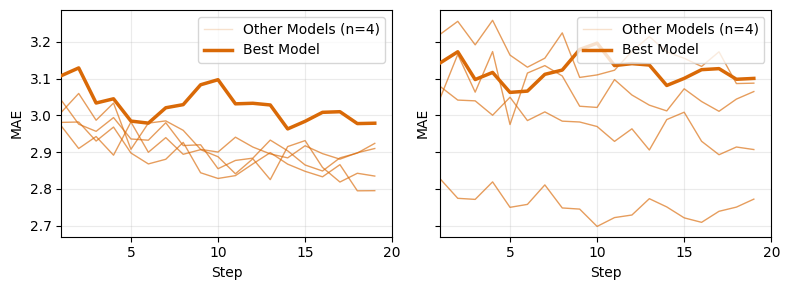

In [65]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- config ---
BERT_BASE_DIR = "data/test_post/bert_regression_finetuned"  # path to the directory containing seed runs
MODEL_SHORT   = "Qwen3.5-27B"
METRIC_KIND   = "auto"  # "auto" | "mae" | "score"
START_EPOCH   = 1       # inclusive
END_EPOCH     = 20    # exclusive; None = no upper cap
CHAMP_COLOR   = "#d96907"
OTHER_COLOR   = "#d96907"

# --- functions ---
def load_seed_run(d, metric_kind):
    try:
        seed = int(d.rsplit("seed", 1)[-1])
    except ValueError:
        return None
    perf_path     = os.path.join(d, "performance.json")
    traj_path     = os.path.join(d, "training_trajectory.csv")
    per_phq9_path = os.path.join(d, "test_scores_phq9.csv")
    if not (os.path.isfile(traj_path) and os.path.isfile(per_phq9_path)):
        print(f"[skip] {d} — missing training_trajectory.csv or test_scores_phq9.csv")
        return None
    traj_df     = pd.read_csv(traj_path)
    per_phq9_df = pd.read_csv(per_phq9_path)
    if os.path.isfile(perf_path):
        with open(perf_path) as fh:
            perf = json.load(fh)
        best_val    = float(perf["best_val_mae"])
        test_metric = float(perf["test_mae"])
    else:
        is_score = metric_kind == "score" or (metric_kind == "auto" and "avg_score" in per_phq9_df.columns)
        val_rows = traj_df[traj_df["split"] == "val"]
        best_val = float("nan") if val_rows.empty else float(
            val_rows["mean_score"].max() if is_score else val_rows["mean_score"].min()
        )
        per_col     = "avg_score" if is_score else "avg_mae"
        ns          = per_phq9_df["n_samples"].to_numpy(dtype=float)
        test_metric = float(np.average(per_phq9_df[per_col].to_numpy(), weights=ns)) if ns.sum() > 0 else float("nan")
    return {"seed": seed, "dir": d, "best_val_mae": best_val, "test_mae": test_metric,
            "trajectory": traj_df, "per_phq9": per_phq9_df}

# --- load data ---
seed_dirs = sorted(glob.glob(os.path.join(BERT_BASE_DIR, f"{MODEL_SHORT}_seed*")))
runs = []
for d in seed_dirs:
    r = load_seed_run(d, METRIC_KIND)
    if r is not None:
        runs.append(r)
if not runs:
    raise FileNotFoundError(f"No seed runs found under {BERT_BASE_DIR}/{MODEL_SHORT}_seed*")

IS_SCORE     = ("avg_score" in runs[0]["per_phq9"].columns) if METRIC_KIND == "auto" else (METRIC_KIND == "score")
METRIC_LABEL = "Score" if IS_SCORE else "MAE"
champion     = (max if IS_SCORE else min)(runs, key=lambda r: r["test_mae"])

print(f"Champion seed: {champion['seed']}  "
      f"(val {METRIC_LABEL}={champion['best_val_mae']:.3f}, test {METRIC_LABEL}={champion['test_mae']:.3f})")
print("All seed runs:")
for r in sorted(runs, key=lambda r: r["seed"]):
    marker = "  champion" if r["seed"] == champion["seed"] else ""
    print(f"  seed={r['seed']:>3}  val {METRIC_LABEL}={r['best_val_mae']:.3f}  "
          f"test {METRIC_LABEL}={r['test_mae']:.3f}{marker}")

# --- plot ---
fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for r in runs:
    df       = r["trajectory"]
    is_champ = r["seed"] == champion["seed"]
    for split, ax in [("train", ax_train), ("val", ax_val)]:
        sub = df[df["split"] == split].sort_values("step")
        sub = sub[sub["step"] >= START_EPOCH]
        if END_EPOCH is not None:
            sub = sub[sub["step"] < END_EPOCH]
        if sub.empty:
            continue
        ax.plot(
            sub["step"], sub["mean_score"],
            color=CHAMP_COLOR if is_champ else OTHER_COLOR,
            linewidth=2.5 if is_champ else 1.0,
            alpha=1.0 if is_champ else 0.65,
            zorder=3 if is_champ else 2,
        )

n_other        = len(runs) - 1
legend_handles = [
    Line2D([0], [0], color=OTHER_COLOR, linewidth=1.0, alpha=0.2, label=f"Other Models (n={n_other})"),
    Line2D([0], [0], color=CHAMP_COLOR, linewidth=2.5, label="Best Model"),
]
for ax, split in [(ax_train, "train"), (ax_val, "val")]:
    sub   = df[df["split"] == split]
    start = max(START_EPOCH, sub["step"].min()) if not sub.empty else START_EPOCH
    end   = sub["step"].max() if END_EPOCH is None else min(END_EPOCH, sub["step"].max())
    ax.set_xlabel("Step")
    ax.set_ylabel(METRIC_LABEL)
    ax.set_xlim(start, end)
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    ax.legend(handles=legend_handles, loc="best")

fig.tight_layout()
plt.savefig(f"{BERT_BASE_DIR}/{MODEL_SHORT}_train_val_{METRIC_LABEL.lower()}_across_seeds.png",
            dpi=300, bbox_inches="tight")
plt.show()


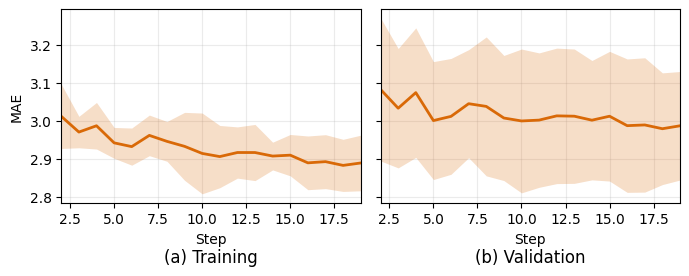

In [66]:
# --- config ---
START_EPOCH_AGG = 2     # inclusive
END_EPOCH_AGG   = 20  # exclusive; None = no upper cap
LINE_COLOR      = "#d96907"
BAND_ALPHA      = 0.22

# --- data preparation ---
long_traj = pd.concat(
    [r["trajectory"].assign(_seed=r["seed"]) for r in runs],
    ignore_index=True,
)
long_traj = long_traj[long_traj["step"] >= START_EPOCH_AGG]
if END_EPOCH_AGG is not None:
    long_traj = long_traj[long_traj["step"] < END_EPOCH_AGG]

# --- plot ---
fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
for split, ax, panel_title in [
    ("train", ax_train, "(a) Training"),
    ("val",   ax_val,   "(b) Validation"),
]:
    sub = long_traj[long_traj["split"] == split]
    if sub.empty:
        ax.set_xlabel("Step")
        ax.set_ylabel(METRIC_LABEL)
        continue
    agg = (
        sub.groupby("step")["mean_score"]
           .agg(["mean", "std", "count"])
           .reset_index()
           .sort_values("step")
    )
    band = agg["std"].fillna(0.0)
    ax.plot(agg["step"], agg["mean"], color=LINE_COLOR, linewidth=2.0,
            label=f"Mean across {len(runs)} seeds")
    ax.fill_between(
        agg["step"], agg["mean"] - band, agg["mean"] + band,
        color=LINE_COLOR, alpha=BAND_ALPHA, linewidth=0, label="±1 SD across seeds",
    )
    start = max(START_EPOCH_AGG, sub["step"].min())
    end   = sub["step"].max() if END_EPOCH_AGG is None else min(END_EPOCH_AGG, sub["step"].max())
    ax.set_xlabel("Step")
    if split == "train":
        ax.set_ylabel(METRIC_LABEL)
    ax.set_title(panel_title, y=-0.35)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(start, end)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.savefig(f"{BERT_BASE_DIR}/{MODEL_SHORT}_mean_sd_{METRIC_LABEL.lower()}_across_seeds.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# === Plot 2: TextGrad vs Human prompts (each vs the minimal prompt), by PHQ-9 severity ===
# All prompts scored on the SAME shared test set (test_posts.csv / test_raw_scores.csv,
# sample_seed 999, 100 personas). Panel (a) = best TextGrad-optimized prompt, panel (b) =
# human-optimized prompt (iter_10); each gets a blue "minimal prompt" (iter_0) bar beside it.
# A 4-row summary table (overall Score +/- SD) is printed below as a DataFrame and as LaTeX.
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- config ---
MODEL_SHORT  = "Qwen3.5-27B"
OPT_DIR      = "data/test_post/optimized_tweets"
TG_SEEDS     = [24, 25, 28, 29, 53]
MINIMAL_DIR  = "data/prompt_optimization_h/qwen27_baseline/iter_0"   # minimal prompt
HUMAN_DIR    = "data/prompt_optimization_h/qwen27_baseline/iter_10"  # human-optimized prompt
ORANGE, BLUE = "#d96907", "#1f77b4"
BAR_W        = 0.40

CATEGORIES = [
    ("(0–4)",   range(0,  5)),
    ("(5–9)",   range(5, 10)),
    ("(10–14)", range(10, 15)),
    ("(15–19)", range(15, 20)),
    ("(20–27)", range(20, 28)),
]

# --- helpers ---
def _scores(d):     return pd.read_csv(os.path.join(d, "test_scores_phq9.csv"))
def _raw(d):        return pd.read_csv(os.path.join(d, "test_raw_scores.csv"))

def overall_score(df):
    w = df["n_samples"].to_numpy(float)
    return float(np.average(df["avg_score"].to_numpy(float), weights=w))

def overall_sd(raw_df):
    return float(raw_df["score"].std(ddof=1))

def per_cat_score(df):
    out = {}
    for lbl, rng in CATEGORIES:
        sub = df[df["phq9"].isin(list(rng))]
        if sub.empty:
            continue
        w = sub["n_samples"].to_numpy(float)
        out[lbl] = float(np.average(sub["avg_score"].to_numpy(float), weights=w))
    return out

def per_cat_sd(raw_df, labels):
    sds = []
    for lbl in labels:
        rng = next(r for c, r in CATEGORIES if c == lbl)
        vals = raw_df[raw_df["phq9"].isin(list(rng))]["score"]
        sds.append(float(vals.std(ddof=1)) if len(vals) > 1 else 0.0)
    return sds

# --- load TextGrad seeds (shared test set) ---
tg = {}
for s in TG_SEEDS:
    d = os.path.join(OPT_DIR, f"{MODEL_SHORT}_seed{s}")
    sc = _scores(d)
    tg[s] = {"dir": d, "scores": sc, "raw": _raw(d), "overall": overall_score(sc)}
tg_champ = max(tg, key=lambda s: tg[s]["overall"])     # best TextGrad prompt
print(f"TextGrad champion seed: {tg_champ}  (overall score = {tg[tg_champ]['overall']:.3f})")

# --- minimal (iter_0) & human (iter_10) ---
min_sc, min_raw = _scores(MINIMAL_DIR), _raw(MINIMAL_DIR)
hum_sc, hum_raw = _scores(HUMAN_DIR),  _raw(HUMAN_DIR)

# --- per-category vectors ---
champ_pc = per_cat_score(tg[tg_champ]["scores"])
labels   = [lbl for lbl, _ in CATEGORIES if lbl in champ_pc]
x        = np.arange(len(labels))

champ_vals = [champ_pc[l] for l in labels]
champ_sd   = per_cat_sd(tg[tg_champ]["raw"], labels)
min_pc     = per_cat_score(min_sc); min_vals = [min_pc[l] for l in labels]
min_sd     = per_cat_sd(min_raw, labels)
hum_pc     = per_cat_score(hum_sc); hum_vals = [hum_pc[l] for l in labels]
hum_sd     = per_cat_sd(hum_raw, labels)

# --- plot: two panels, orange (main) + blue (minimal) bars side by side ---
fig, (ax_tg, ax_hu) = plt.subplots(1, 2, figsize=(7.6, 3.8), sharey=True)
off = BAR_W / 2

def _panel(ax, main_vals, main_sd, main_label, main_color):
    ax.bar(x - off, main_vals, BAR_W, color=main_color, edgecolor="white",
           linewidth=0.8, alpha=0.85, label=main_label, zorder=2)
    ax.bar(x + off, min_vals, BAR_W, color=BLUE, edgecolor="white",
           linewidth=0.8, alpha=0.85, label="Minimal", zorder=2)
    ax.errorbar(x - off, main_vals, yerr=main_sd, fmt="none", ecolor="black",
                capsize=3.5, elinewidth=1.2, zorder=5)
    ax.errorbar(x + off, min_vals, yerr=min_sd, fmt="none", ecolor="black",
                capsize=3.5, elinewidth=1.2, zorder=5)

_panel(ax_tg, champ_vals, champ_sd, "TextGrad (best)", ORANGE)
_panel(ax_hu, hum_vals,  hum_sd,   "Human", ORANGE)

for ax in (ax_tg, ax_hu):
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Depression severity", labelpad=8)
    ax.grid(True, axis="y", alpha=0.25); ax.set_axisbelow(True)

ax_tg.set_ylabel("Score")
ax_tg.set_ylim(0, 10)
ax_tg.set_title("(a) TextGrad", y=-0.42)
ax_hu.set_title("(b) Human", y=-0.42)
ax_tg.legend(handles=[Patch(facecolor=ORANGE, label="TextGrad (best)"),
                      Patch(facecolor=BLUE, label="Minimal")], fontsize=8, frameon=False,
             ncol=2, loc="upper center", columnspacing=1.2, handlelength=1.4)
ax_hu.legend(handles=[Patch(facecolor=ORANGE, label="Human"),
                      Patch(facecolor=BLUE, label="Minimal")], fontsize=8, frameon=False,
             ncol=2, loc="upper center", columnspacing=1.2, handlelength=1.4)

fig.tight_layout()
OUT_PNG = "plots/textgrad_human_vs_minimal_score_per_phq9.png"
os.makedirs("plots", exist_ok=True)
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot saved at {OUT_PNG}")

# --- summary table: overall Score +/- SD (4 rows) ---
tg_overalls = np.array([tg[s]["overall"] for s in TG_SEEDS], float)
rows = [
    ("TextGrad (mean across seeds)", tg_overalls.mean(), tg_overalls.std(ddof=1), "across seeds"),
    (f"TextGrad (best, seed {tg_champ})", tg[tg_champ]["overall"], overall_sd(tg[tg_champ]["raw"]), "in-sample"),
    ("Minimal (iter_0)", overall_score(min_sc), overall_sd(min_raw), "in-sample"),
    ("Human (iter_10)",  overall_score(hum_sc), overall_sd(hum_raw), "in-sample"),
]
summary = pd.DataFrame(rows, columns=["Prompt", "Score", "SD", "SD basis"])
summary_disp = summary.assign(**{"Score ± SD": [f"{s:.2f} ± {sd:.2f}" for s, sd in zip(summary.Score, summary.SD)]})
summary_disp = summary_disp[["Prompt", "Score ± SD", "SD basis"]].set_index("Prompt")
print("\n=== Overall summary (shared test set) ===")
try:
    from IPython.display import display
    display(summary_disp)
except Exception:
    print(summary_disp.to_string())

# LaTeX (booktabs)
def _esc(t): return t.replace("_", r"\_")
latex = ["\\begin{tabular}{lc}", "\\toprule", "Prompt & Score \\\\", "\\midrule"]
latex += [f"{_esc(p)} & ${s:.2f} \\pm {sd:.2f}$ \\\\" for p, s, sd, _ in rows]
latex += ["\\bottomrule", "\\end{tabular}",
          "% SD: TextGrad(mean)=across seeds; others=in-sample (per-post)."]
print("\n=== LaTeX ===")
print("\n".join(latex))


saved -> data/test_post/bert_regression_finetuned/Qwen3.5-27B_biasfit_and_forward.png
full-fit table     -> data/test_post/bert_regression_finetuned/Qwen3.5-27B_seed35/phq9_bias_table_fullfit.csv
interior-fit table -> data/test_post/bert_regression_finetuned/Qwen3.5-27B_seed35/phq9_bias_table_interiorfit.csv


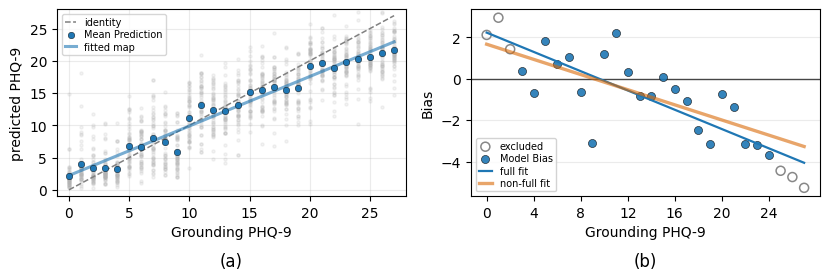

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Combined figure: (a) forward map (regressor output vs the grounding PHQ-9),
# (b) regressor bias + linear fits. Same seed-35 calibration data.
RAW   = "data/test_post/bert_regression_finetuned/eval_calibration/seed35.csv"
N = 28
EXCLUDE_ENDS = 3
BLUE, ORANGE, GREY = "#1f77b4", "#d96907", "#888888"

# --- regressor bias + two linear fits (panel b), from the raw calibration eval ---
_cal   = pd.read_csv(RAW)
_k     = _cal["true_phq9"].round().astype(int).clip(0, N - 1)
_g     = (_cal["raw_pred"] - _cal["true_phq9"]).groupby(_k)
levels = np.array(sorted(_g.groups))
b      = _g.mean().reindex(levels).to_numpy()
n      = _g.size().reindex(levels).to_numpy(float)
coef_all = np.polyfit(levels, b, 1, w=n)
fit_m    = (levels >= EXCLUDE_ENDS) & (levels <= N - 1 - EXCLUDE_ENDS)
coef_in  = np.polyfit(levels[fit_m], b[fit_m], 1, w=n[fit_m])
xs = np.array([0.0, N - 1])

# --- forward: E[pred | true] (panel a) ---
raw = pd.read_csv(RAW)
T = raw["true_phq9"].to_numpy(float); P = raw["raw_pred"].to_numpy(float)
kt  = np.clip(np.round(T).astype(int), 0, N - 1)
fwd = pd.DataFrame({"k": kt, "P": P}).groupby("k")
flv = np.array(sorted(fwd.groups))
fP  = fwd["P"].mean().reindex(flv).to_numpy(); fn = fwd.size().reindex(flv).to_numpy(float)
sP  = np.polyfit(flv, fP, 1, w=fn)
xx = np.array([0, N - 1])

fig, ax = plt.subplots(1, 2, figsize=(8.4, 2.8))

# panel (a) -- forward map (left)
ax[0].plot(xx, xx, ls="--", c="0.5", lw=1.1, zorder=1, label="identity")
ax[0].scatter(T, P, s=5, c="0.7", alpha=0.15, zorder=0)
ax[0].scatter(flv, fP, s=22, c=BLUE, ec="k", lw=.3, zorder=3, label="Mean Prediction")
ax[0].plot(xx, np.polyval(sP, xx), c=BLUE, lw=2.2, alpha=0.6, zorder=2, label="fitted map")
ax[0].set_xlabel("Grounding PHQ-9")
ax[0].set_ylabel("predicted PHQ-9")
ax[0].set_xlim(-1, N); ax[0].set_ylim(-1, N)
ax[0].grid(alpha=.25); ax[0].set_axisbelow(True)
ax[0].legend(fontsize=7, loc="upper left", framealpha=0.8,
             handlelength=1.2, borderpad=0.3, labelspacing=0.25)

# panel (b) -- regressor bias + linear fits (right)
ax[1].axhline(0, color="black", linewidth=1.0, alpha=0.7)
ax[1].scatter(levels[~fit_m], b[~fit_m], facecolors="none", edgecolors=GREY,
              s=42, linewidth=1.1, zorder=3, label="excluded")
ax[1].scatter(levels[fit_m], b[fit_m], color=BLUE, s=34, alpha=0.9,
              edgecolor="black", linewidth=0.4, zorder=4, label="Model Bias")
ax[1].plot(xs, np.polyval(coef_all, xs), color=BLUE, linewidth=1.6, linestyle="-",
           zorder=5, label="full fit")
ax[1].plot(xs, np.polyval(coef_in, xs), color=ORANGE, linewidth=2.4, alpha=0.6,
           zorder=6, label="non-full fit")
ax[1].set_xlabel("Grounding PHQ-9")
ax[1].set_ylabel("Bias")
ax[1].set_xticks(np.arange(0, N, 4))
ax[1].grid(True, axis="y", alpha=0.25); ax[1].set_axisbelow(True)
ax[1].legend(fontsize=7, loc="lower left", framealpha=0.85,
             handlelength=1.4, borderpad=0.3, labelspacing=0.25)

fig.tight_layout(rect=[0, 0.07, 1, 1])
for a, lab in zip(ax, ["(a)", "(b)"]):
    pos = a.get_position()
    fig.text((pos.x0 + pos.x1) / 2, 0.015, lab, ha="center", va="bottom", fontsize=12)
out = "data/test_post/bert_regression_finetuned/Qwen3.5-27B_biasfit_and_forward.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved ->", out)

# export the two correction tables the simulation loads via --bias_table_path
import os, csv

REG_DIR = "data/test_post/bert_regression_finetuned/Qwen3.5-27B_seed35"
_grid   = np.arange(N)
_counts = pd.Series(n, index=levels).reindex(_grid).fillna(0).astype(int).to_numpy()
def _save_table(coef, name):
    p = os.path.join(REG_DIR, name)
    with open(p, "w", newline="") as f:
        wtr = csv.writer(f); wtr.writerow(["phq9", "bias", "count"])
        for kk in range(N):
            wtr.writerow([kk, round(float(np.polyval(coef, kk)), 6), int(_counts[kk])])
    return p
print("full-fit table     ->", _save_table(coef_all, "phq9_bias_table_fullfit.csv"))
print("interior-fit table ->", _save_table(coef_in,  "phq9_bias_table_interiorfit.csv"))
plt.show()
plt.close()


### Held-out comparison: TextGrad-optimized vs minimal prompt (per PHQ-9 severity)

Both prompts scored on the **same** MentalBERT held-out blocks (`run_phq9_on_bert_testset.sh`), stratified by PHQ-9 severity category. Requires the minimal re-run that writes to `eval_on_test_blocks_seed35_minimal/` (the original minimal output was overwritten by the optimized seed-23 run; the script is now patched so it lands in a distinct subdir).

saved -> data/test_post/optimized_phq9/Qwen3.5-27B_minimal_vs_textgrad_per_phq9.png


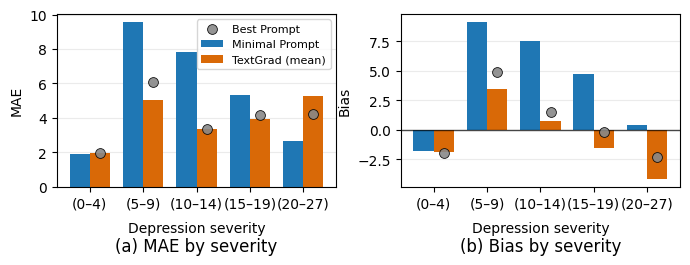

In [33]:
# === Held-out: TextGrad-optimized PHQ-9 prompts vs the minimal prompt, by severity ===
# Both scored on the SAME MentalBERT test blocks (run_phq9_on_bert_testset.sh).
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# --- config ---
MODEL_SHORT    = "Qwen3.5-27B"
OPT_DIR        = "data/test_post/optimized_phq9"
OPT_SEEDS      = [23, 24, 25, 32, 33]
EVAL_SUBDIR    = "eval_on_test_blocks_seed35"           # optimized prompts on the BERT blocks
MINIMAL_SEED   = 23
BEST_SEED = 32
MINIMAL_SUBDIR = "eval_on_test_blocks_seed35_minimal"   # minimal prompt on the same blocks (re-run)
OPT_COLOR, MIN_COLOR = "#d96907", "#1f77b4"

DOT_SIZE    = 50

CATEGORIES = [
    ("(0–4)",   range(0,  5)),
    ("(5–9)",   range(5, 10)),
    ("(10–14)", range(10, 15)),
    ("(15–19)", range(15, 20)),
    ("(20–27)", range(20, 28)),
]

def _agg(df, col):
    """Sample-weighted value of `col` per severity category -> {label: value}."""
    out = {}
    for label, rng in CATEGORIES:
        sub = df[df["phq9"].isin(list(rng))]
        if sub.empty:
            continue
        w = sub["n_samples"].to_numpy(float)
        out[label] = float(np.average(sub[col].to_numpy(float), weights=w))
    return out

# --- load optimized (per seed) ---
opt_mae, opt_bias = {}, {}
for s in OPT_SEEDS:
    p = os.path.join(OPT_DIR, f"{MODEL_SHORT}_seed{s}", EVAL_SUBDIR, "test_scores_phq9.csv")
    if not os.path.isfile(p):
        print(f"[skip] missing {p}"); continue
    df = pd.read_csv(p)
    opt_mae[s], opt_bias[s] = _agg(df, "avg_mae"), _agg(df, "avg_bias")
assert opt_mae, "no optimized held-out CSVs found"

# --- load minimal (single run) ---
min_path = os.path.join(OPT_DIR, f"{MODEL_SHORT}_seed{MINIMAL_SEED}", MINIMAL_SUBDIR, "test_scores_phq9.csv")
have_min = os.path.isfile(min_path)
if have_min:
    mdf = pd.read_csv(min_path)
    min_mae, min_bias = _agg(mdf, "avg_mae"), _agg(mdf, "avg_bias")
else:
    print(f"[!] minimal not on disk at {min_path}\n"
          f"    It was overwritten by the optimized seed-{MINIMAL_SEED} run. Re-score it (GPU session):\n"
          f"      bash run_phq9_on_bert_testset.sh        # patched -> writes {MINIMAL_SUBDIR}\n"
          f"    Plotting optimized only for now.")

labels = [lbl for lbl, _ in CATEGORIES if lbl in next(iter(opt_mae.values()))]
x = np.arange(len(labels)); w = 0.38
opt_mae_mean  = np.array([np.mean([opt_mae[s][l]  for s in opt_mae  if l in opt_mae[s]])  for l in labels])
opt_bias_mean = np.array([np.mean([opt_bias[s][l] for s in opt_bias if l in opt_bias[s]]) for l in labels])

fig, (ax_mae, ax_bias) = plt.subplots(1, 2, figsize=(7, 3.0), sharex=False)
jit = np.random.default_rng(0)

# panel (a): MAE
if have_min:
    ax_mae.bar(x - w/2, [min_mae[l] for l in labels], w, color=MIN_COLOR, alpha=1,
               label="Minimal Prompt")
    ax_mae.bar(x + w/2, opt_mae_mean, w, color=OPT_COLOR, alpha=1,
                label="TextGrad (mean)")
    xo = x + w/2
else:
    ax_mae.bar(x, opt_mae_mean, w*1.4, color=OPT_COLOR, alpha=1, edgecolor="white",
               label="TextGrad (mean)")
    xo = x
for s in opt_mae:  # per-seed optimized spread
    if s == BEST_SEED:
        ax_mae.scatter(xo ,
                       [opt_mae[s].get(l, np.nan) for l in labels],
                       color="#888888", s=DOT_SIZE, alpha=0.9,  edgecolor="black", linewidth=0.6, zorder=4, label="Best Prompt")
ax_mae.set_ylabel("MAE"); ax_mae.set_title("(a) MAE by severity", y=-0.42)

# panel (b): bias
ax_bias.axhline(0, color="black", lw=1.0, alpha=0.7)
if have_min:
    ax_bias.bar(x - w/2, [min_bias[l] for l in labels], w, color=MIN_COLOR, alpha=1,
               label="Minimal Prompt")
    ax_bias.bar(x + w/2, opt_bias_mean, w, color=OPT_COLOR, alpha=1,
                label="TextGrad (mean)")
else:
    ax_bias.bar(x, opt_bias_mean, w*1.4, color=OPT_COLOR, alpha=1, edgecolor="white")
ax_bias.set_ylabel("Bias"); ax_bias.set_title("(b) Bias by severity", y=-0.42)
for s in opt_bias:  # per-seed optimized spread
    if s == BEST_SEED:
        ax_bias.scatter(xo ,
                        [opt_bias[s].get(l, np.nan) for l in labels],
                        color="#888888", s=DOT_SIZE, alpha=0.9,  edgecolor="black", linewidth=0.6, zorder=4)

for ax in (ax_mae, ax_bias):
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Depression severity", labelpad=8)
    ax.grid(True, axis="y", alpha=0.25); ax.set_axisbelow(True)
ax_mae.legend(fontsize=8, loc="best")

fig.tight_layout()
out = os.path.join(OPT_DIR, f"{MODEL_SHORT}_minimal_vs_textgrad_per_phq9.png")
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved ->", out)
plt.show()


In [ ]:
# === Summary table: PHQ-9 ASSESSMENT prompt on the 1125-block held-out set ===
# Counterpart of the post-generation summary table, but for the PHQ-9 *assessment* prompt
# scored on the shared MentalBERT test blocks (1125 blocks). Metric = MAE (lower is better);
# Bias = mean(pred - true). There is no human-optimized assessment prompt, so the table has
# three rows: TextGrad mean-across-seeds, best TextGrad prompt (seed 23 = lowest MAE), minimal.
import os
import numpy as np, pandas as pd

# --- config ---
MODEL_SHORT    = "Qwen3.5-27B"
OPT_DIR        = "data/test_post/optimized_phq9"
OPT_SEEDS      = [23, 24, 25, 32, 33]
EVAL_SUBDIR    = "eval_on_test_blocks_seed35"            # optimized assessment prompt on the blocks
MINIMAL_SEED   = 23
MINIMAL_SUBDIR = "eval_on_test_blocks_seed35_minimal"    # minimal assessment prompt on the same blocks

def _dir(seed, sub):  return os.path.join(OPT_DIR, f"{MODEL_SHORT}_seed{seed}", sub)
def _scores(d):       return pd.read_csv(os.path.join(d, "test_scores_phq9.csv"))
def _raw(d):          return pd.read_csv(os.path.join(d, "test_raw_scores.csv"))

def overall_mae(df):                       # sample-weighted MAE across severities
    w = df["n_samples"].to_numpy(float)
    return float(np.average(df["avg_mae"].to_numpy(float), weights=w))
def overall_bias(df):
    w = df["n_samples"].to_numpy(float)
    return float(np.average(df["avg_bias"].to_numpy(float), weights=w))
def insample_mae_sd(raw_df):               # SD of |pred - true| over all blocks
    return float((raw_df["true_phq9"] - raw_df["pred_phq9"]).abs().std(ddof=1))

# --- TextGrad-optimized seeds ---
tg = {}
for s in OPT_SEEDS:
    d = _dir(s, EVAL_SUBDIR)
    sc = _scores(d)
    tg[s] = {"mae": overall_mae(sc), "bias": overall_bias(sc), "sd": insample_mae_sd(_raw(d)),
             "n": len(_raw(d))}
champ = min(tg, key=lambda s: tg[s]["mae"])           # best = lowest MAE (seed 23)
tg_mae  = np.array([tg[s]["mae"]  for s in OPT_SEEDS], float)
tg_bias = np.array([tg[s]["bias"] for s in OPT_SEEDS], float)

# --- minimal assessment prompt (single eval, lives under seed 23) ---
md = _dir(MINIMAL_SEED, MINIMAL_SUBDIR)
msc = _scores(md)
min_mae, min_bias, min_sd = overall_mae(msc), overall_bias(msc), insample_mae_sd(_raw(md))
n_blocks = len(_raw(md))
print(f"Assessment champion seed: {champ} (MAE={tg[champ]['mae']:.3f}); evaluated on {n_blocks} blocks")

# --- table (MAE +/- SD, Bias) ---
rows = [
    ("TextGrad (mean across seeds)", tg_mae.mean(), tg_mae.std(ddof=1), tg_bias.mean(), "across seeds"),
    (f"TextGrad (best, seed {champ})", tg[champ]["mae"], tg[champ]["sd"], tg[champ]["bias"], "in-sample"),
    ("Minimal", min_mae, min_sd, min_bias, "in-sample"),
]
summary = pd.DataFrame(rows, columns=["Prompt", "MAE", "SD", "Bias", "SD basis"])
summary_disp = summary.assign(**{"MAE ± SD": [f"{m:.2f} ± {sd:.2f}" for m, sd in zip(summary.MAE, summary.SD)],
                                 "Bias": summary.Bias.map(lambda b: f"{b:+.2f}")})
summary_disp = summary_disp[["Prompt", "MAE ± SD", "Bias", "SD basis"]].set_index("Prompt")
print(f"\n=== PHQ-9 assessment prompt — held-out {n_blocks}-block set ===")
try:
    from IPython.display import display
    display(summary_disp)
except Exception:
    print(summary_disp.to_string())

# --- LaTeX (booktabs) ---
latex = ["\\begin{tabular}{lcc}", "\\toprule",
         "Prompt & MAE & Bias \\\\", "\\midrule"]
latex += [f"{p} & ${m:.2f} \\pm {sd:.2f}$ & ${b:+.2f}$ \\\\" for p, m, sd, b, _ in rows]
latex += ["\\bottomrule", "\\end{tabular}",
          "% MAE on 1125 held-out MentalBERT blocks. SD: TextGrad(mean)=across seeds; others=in-sample |error|."]
print("\n=== LaTeX ===")
print("\n".join(latex))


In [ ]:
# === Summary table: MentalBERT+MLP regressor on the held-out blocks ===
# Same format as the PHQ-9 assessment-prompt table, but the estimator is the trained
# MentalBERT(frozen)+MLP regressor (data/test_post/bert_regression). Each seed is scored on
# its own ~1100-1235-block 10% holdout (seed35's = the 1125 blocks used above). No prompt
# baseline applies, so the table has two rows: mean across seeds, and the best seed (lowest MAE).
import os, json
import numpy as np, pandas as pd

# --- config ---
MODEL_SHORT = "Qwen3.5-27B"
BERT_DIR    = "data/test_post/bert_regression"       # non-finetuned MentalBERT + MLP head
BERT_SEEDS  = [34, 35, 36, 37, 38]

def _dir(seed):  return os.path.join(BERT_DIR, f"{MODEL_SHORT}_seed{seed}")
def _scores(d):  return pd.read_csv(os.path.join(d, "test_scores_phq9.csv"))
def _raw(d):     return pd.read_csv(os.path.join(d, "test_raw_scores.csv"))

def overall_mae(df):
    w = df["n_samples"].to_numpy(float)
    return float(np.average(df["avg_mae"].to_numpy(float), weights=w))
def overall_bias(df):
    w = df["n_samples"].to_numpy(float)
    return float(np.average(df["avg_bias"].to_numpy(float), weights=w))
def insample_mae_sd(raw_df):                          # SD of |pred - true| over the holdout blocks
    return float((raw_df["true_phq9"] - raw_df["pred_phq9"]).abs().std(ddof=1))

# --- load all seeds ---
bert = {}
for s in BERT_SEEDS:
    d = _dir(s); sc = _scores(d); raw = _raw(d)
    bert[s] = {"mae": overall_mae(sc), "bias": overall_bias(sc),
               "sd": insample_mae_sd(raw), "n": len(raw)}
champ   = min(bert, key=lambda s: bert[s]["mae"])     # best = lowest MAE
mae_arr  = np.array([bert[s]["mae"]  for s in BERT_SEEDS], float)
bias_arr = np.array([bert[s]["bias"] for s in BERT_SEEDS], float)
print(f"MentalBERT+MLP best seed: {champ} (MAE={bert[champ]['mae']:.3f}, n={bert[champ]['n']} blocks)")

# --- table (MAE +/- SD, Bias), two rows ---
rows = [
    ("MentalBERT+MLP (mean across seeds)", mae_arr.mean(), mae_arr.std(ddof=1), bias_arr.mean(), "across seeds"),
    (f"MentalBERT+MLP (best, seed {champ})", bert[champ]["mae"], bert[champ]["sd"], bert[champ]["bias"], "in-sample"),
]
summary = pd.DataFrame(rows, columns=["Model", "MAE", "SD", "Bias", "SD basis"])
summary_disp = summary.assign(**{"MAE ± SD": [f"{m:.2f} ± {sd:.2f}" for m, sd in zip(summary.MAE, summary.SD)],
                                 "Bias": summary.Bias.map(lambda b: f"{b:+.2f}")})
summary_disp = summary_disp[["Model", "MAE ± SD", "Bias", "SD basis"]].set_index("Model")
print("\n=== MentalBERT+MLP regressor — held-out blocks ===")
try:
    from IPython.display import display
    display(summary_disp)
except Exception:
    print(summary_disp.to_string())

# --- LaTeX (booktabs) ---
latex = ["\\begin{tabular}{lcc}", "\\toprule", "Model & MAE & Bias \\\\", "\\midrule"]
latex += [f"{m} & ${mae:.2f} \\pm {sd:.2f}$ & ${b:+.2f}$ \\\\" for m, mae, sd, b, _ in rows]
latex += ["\\bottomrule", "\\end{tabular}",
          "% MentalBERT(frozen)+MLP on per-seed ~1.1k-block holdouts (seed35=1125)."
          " SD: mean row=across seeds; best row=in-sample |error|."]
print("\n=== LaTeX ===")
print("\n".join(latex))
